In [1]:
import os 
os.chdir('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/GNN_models/DGI_RESULTS/GATv2/AttenPool/')

In [1]:
import torch
from torch_geometric.utils import to_undirected
import os

os.chdir('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/')

graphs_dir = './PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/PatientGraphs/Static/'

patient_graphs = {}

for file_name in os.listdir(graphs_dir):
    if file_name.endswith('_graph.pt'):
        # Extract patient ID and convert to int
        patient_id_str = file_name.replace('_graph.pt', '')
        try:
            patient_id = int(patient_id_str)
        except ValueError:
            print(f"Could not convert '{patient_id_str}' to int. Skipping.")
            continue

        # Load the graph
        graph = torch.load(os.path.join(graphs_dir, file_name), weights_only=False)

        if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
            # If edge attributes are present, use the to_undirected function with edge_attr
            graph.edge_index, graph.edge_attr = to_undirected(
                graph.edge_index, edge_attr=graph.edge_attr, num_nodes=graph.num_nodes, reduce='mean'
            )
        else:
            # If no edge attributes are present (which won't happen here), just make the graph undirected
            graph.edge_index = to_undirected(graph.edge_index, num_nodes=graph.num_nodes)

        # Store the graph in the dictionary
        patient_graphs[patient_id] = graph

        # Optionally, print some information about the graph as loaded
        print(f"Loaded graph for patient ID: {patient_id}")
        print(f"Edge index shape: {graph.edge_index.shape}")
        print(f"Edge attributes shape: {graph.edge_attr.shape}")

# After loading all graphs, print summary of loaded patient graphs
print("\nSummary of loaded patient graphs:")
for pid, graph in patient_graphs.items():
    print(f"Patient ID: {pid}")
    print(f"  Number of nodes: {graph.num_nodes}")
    print(f"  Edge index shape: {graph.edge_index.shape}")
    if graph.edge_attr is not None:
        print(f"  Edge attributes shape: {graph.edge_attr.shape}")
    else:
        print("  No edge attributes")
    print(f"  Node feature shape: {graph.x.shape}")
    print("-" * 40)


/home/vascul/vsayyalasomayajula/my-scratch/PythonEnvs/GNN/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/vascul/vsayyalasomayajula/PythonEnvs/GNN/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/vascul/vsayyalasomayajula/my-scratch/PythonEnvs/GNN/lib/python3.12/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/vascul/vsayyalasomayajula/PythonEnvs/GNN/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


Loaded graph for patient ID: 20
Edge index shape: torch.Size([2, 171832])
Edge attributes shape: torch.Size([171832])
Loaded graph for patient ID: 37
Edge index shape: torch.Size([2, 171832])
Edge attributes shape: torch.Size([171832])
Loaded graph for patient ID: 62
Edge index shape: torch.Size([2, 171832])
Edge attributes shape: torch.Size([171832])
Loaded graph for patient ID: 26
Edge index shape: torch.Size([2, 171832])
Edge attributes shape: torch.Size([171832])
Loaded graph for patient ID: 91
Edge index shape: torch.Size([2, 171832])
Edge attributes shape: torch.Size([171832])
Loaded graph for patient ID: 94
Edge index shape: torch.Size([2, 171832])
Edge attributes shape: torch.Size([171832])
Loaded graph for patient ID: 7
Edge index shape: torch.Size([2, 171832])
Edge attributes shape: torch.Size([171832])
Loaded graph for patient ID: 39
Edge index shape: torch.Size([2, 171832])
Edge attributes shape: torch.Size([171832])
Loaded graph for patient ID: 95
Edge index shape: torch.S

In [3]:
import numpy as np
array_data = np.load('embeddings_array.npy', allow_pickle=True)
dict_data = np.load('embeddings_dict.npy', allow_pickle=True)

In [8]:
print(type(array_data))
print(array_data)  # See what it contains


<class 'numpy.ndarray'>
{'patient_ids': [20, 37, 62, 26, 91, 94, 7, 39, 95, 14, 87, 8, 77, 96, 22, 18, 23, 72, 75, 53, 57, 32, 69, 93, 21, 66, 73, 38, 86, 34, 24, 9, 46, 1, 25, 92, 6, 61, 70, 79, 16, 83, 41, 10, 78, 30, 11, 76, 50, 90, 82, 63, 5, 29, 60, 89, 31, 43, 33, 74, 35, 85, 4, 64, 17, 48, 52, 12, 47, 67, 81, 36, 13, 45, 80, 68, 19, 15, 55, 54, 88, 71, 2, 49, 3], 'avg_embeddings': array([[ 0.03365252, -0.00120384,  0.01603254, ..., -0.02488889,
         0.02235249, -0.05054735],
       [ 0.04586132,  0.00328214,  0.00979681, ..., -0.02703925,
         0.01553565, -0.0422613 ],
       [ 0.03613315,  0.00067378,  0.01402493, ..., -0.02641631,
         0.02057223, -0.04889408],
       ...,
       [ 0.0330543 , -0.00091258,  0.01499181, ..., -0.02580251,
         0.02269899, -0.05077646],
       [ 0.03470677,  0.00171607,  0.01094286, ..., -0.02911519,
         0.02196963, -0.05127055],
       [ 0.03098654, -0.00195704,  0.01695949, ..., -0.02537219,
         0.02377095, -0.05168161

In [9]:
data = array_data.item() 

print(type(data))  

patient_ids = data['patient_ids']
avg_embeddings = data['avg_embeddings']
std_embeddings = data['std_embeddings']

print(f"Number of patients: {len(patient_ids)}")
print(f"Shape of avg_embeddings: {avg_embeddings.shape}")
print(f"Shape of std_embeddings: {std_embeddings.shape}")


<class 'dict'>
Number of patients: 85
Shape of avg_embeddings: (85, 128)
Shape of std_embeddings: (85, 128)


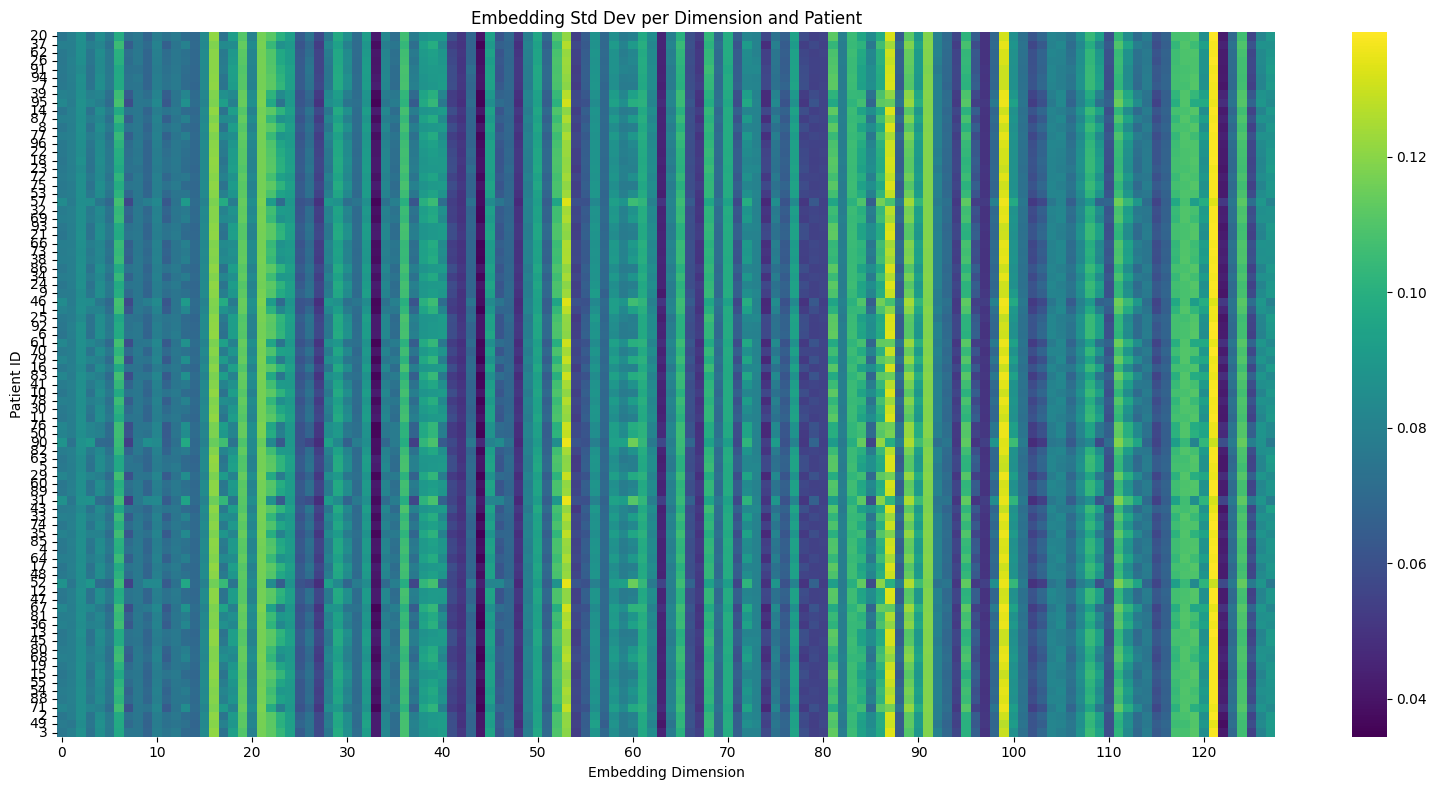

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
sns.heatmap(std_embeddings, cmap="viridis", xticklabels=10, yticklabels=patient_ids)
plt.xlabel("Embedding Dimension")
plt.ylabel("Patient ID")
plt.title("Embedding Std Dev per Dimension and Patient")
plt.tight_layout()
plt.show()


In [12]:
i=10
patient_i_std = std_embeddings[i]
top_dims = np.argsort(-patient_i_std)[:5]  # Top 5 dimensions with highest std

print(f"Patient {patient_ids[i]}'s top 5 high-variance embedding dimensions: {top_dims}")


Patient 87's top 5 high-variance embedding dimensions: [121  99  53  87  91]


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = np.load('embeddings_array.npy', allow_pickle=True).item()
patient_ids = data['patient_ids']
std_embeddings = data['std_embeddings']

avg_std_per_patient = std_embeddings.mean(axis=1)
sorted_indices = np.argsort(-avg_std_per_patient)

print("Top 10 patients by average embedding std:")
for idx in sorted_indices[:10]:
    print(f"Patient ID: {patient_ids[idx]}, Avg STD: {avg_std_per_patient[idx]:.4f}")

sorted_std_embeddings = std_embeddings[sorted_indices]

i = sorted_indices[0]
patient_std = std_embeddings[i]
top_dims = np.argsort(-patient_std)[:5]
print(f"\nTop 5 high-variance dimensions for Patient {patient_ids[i]}: {top_dims}")
print(f"Std values: {patient_std[top_dims]}")


Top 10 patients by average embedding std:
Patient ID: 6, Avg STD: 0.0814
Patient ID: 21, Avg STD: 0.0813
Patient ID: 25, Avg STD: 0.0813
Patient ID: 17, Avg STD: 0.0813
Patient ID: 8, Avg STD: 0.0813
Patient ID: 3, Avg STD: 0.0813
Patient ID: 86, Avg STD: 0.0813
Patient ID: 14, Avg STD: 0.0813
Patient ID: 94, Avg STD: 0.0813
Patient ID: 15, Avg STD: 0.0813

Top 5 high-variance dimensions for Patient 6: [121  87  99  16  53]
Std values: [0.13780901 0.13333292 0.13054216 0.1209559  0.11968324]


Mean of per-patient embedding means: 0.0021452
Std of per-patient embedding means: 0.00032942838


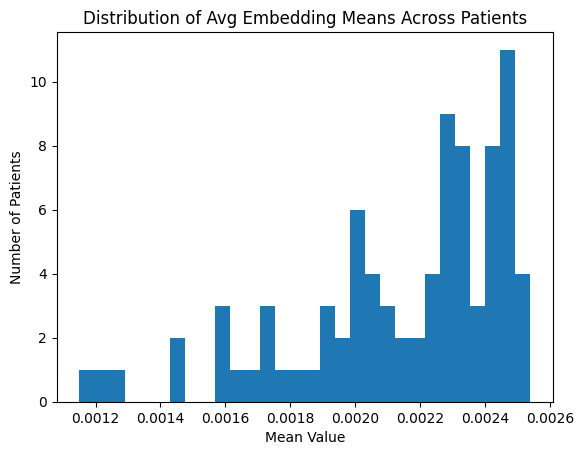

In [17]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('embeddings_array.npy', allow_pickle=True).item()
avg_embeddings = data['avg_embeddings']

avg_emb_means = np.mean(avg_embeddings, axis=1)
print("Mean of per-patient embedding means:", avg_emb_means.mean())
print("Std of per-patient embedding means:", avg_emb_means.std())

plt.hist(avg_emb_means, bins=30)
plt.title("Distribution of Avg Embedding Means Across Patients")
plt.xlabel("Mean Value")
plt.ylabel("Number of Patients")
plt.show()


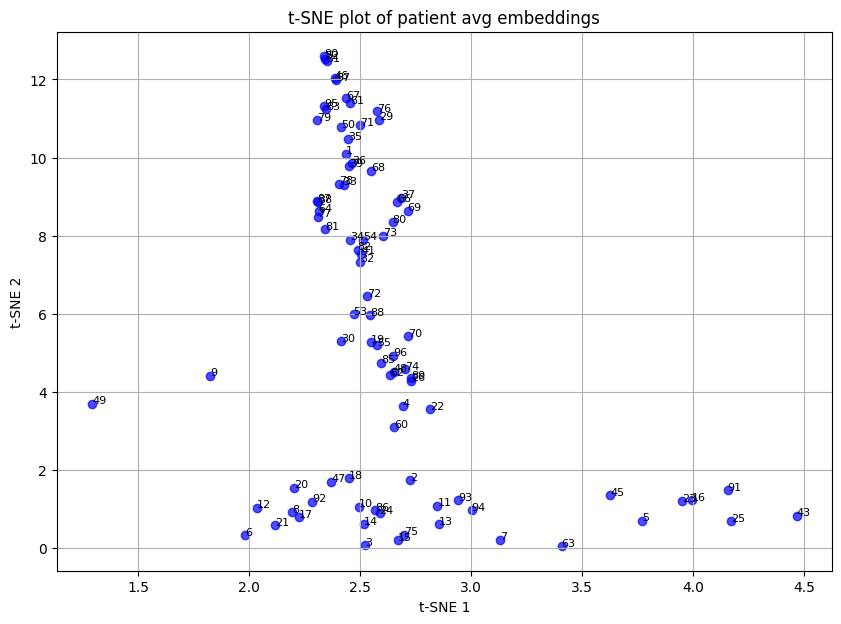

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
data = np.load('embeddings_array.npy', allow_pickle=True).item()
avg_embeddings = data['avg_embeddings']
patient_ids = data['patient_ids']

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(avg_embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='blue', alpha=0.7)

for i, pid in enumerate(patient_ids):
    plt.text(embeddings_2d[i, 0], embeddings_2d[i, 1], str(pid), fontsize=8)

plt.title('t-SNE plot of patient avg embeddings')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True)
plt.show()


/home/vascul/vsayyalasomayajula/my-scratch/miniconda3/envs/GNN/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


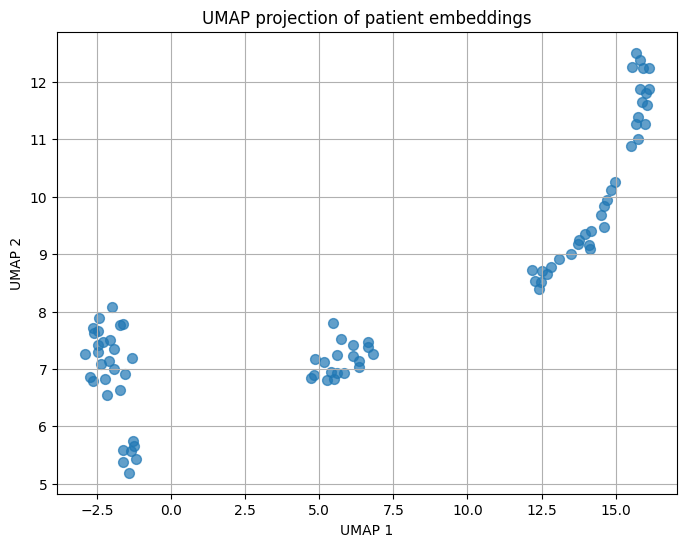

In [19]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_umap = reducer.fit_transform(avg_embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(embedding_umap[:, 0], embedding_umap[:, 1], s=50, alpha=0.7)
plt.title("UMAP projection of patient embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()
